Problem Type: Image Classification

This dataset represents an image classification problem because each image belongs to one predefined category such as normal, scratch, dent, or stain.

The goal of the CNN model is to analyze the input image and classify it into one of these four defect classes.

Image classification is appropriate because:
- Each image has a single label
- The model predicts one class per image
- The dataset contains categorized defect images
- CNNs are highly effective for learning visual patterns such as scratches, dents, and stains

This problem is useful in manufacturing quality inspection where defective products can be automatically identified using computer vision.

In [17]:
import os

dataset_path = "dataset/part_2_cnn_computer_vision/images"

classes = os.listdir(dataset_path)

print("Classes:", classes)
print("Number of classes:", len(classes))

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    classes = [cls for cls in os.listdir(dataset_path) if cls != '.DS_Store']

Classes: ['.DS_Store', 'dent', 'normal', 'scratch', 'stain']
Number of classes: 5


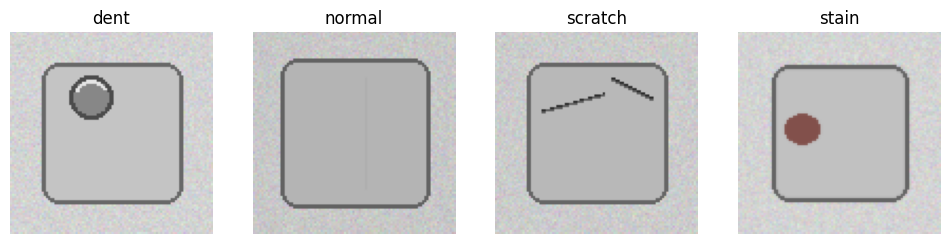

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    # get only image files
    image_files = [f for f in os.listdir(class_path)
                   if f.endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

    img_name = image_files[0]

    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [19]:
classes = [cls for cls in os.listdir(dataset_path) if cls != '.DS_Store']

print(classes)
print("Number of classes:", len(classes))

['dent', 'normal', 'scratch', 'stain']
Number of classes: 4


In [20]:
for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    print(f"{cls} image size:", img.size)

dent image size: (96, 96)
normal image size: (96, 96)
scratch image size: (96, 96)
stain image size: (96, 96)


Dataset Exploration Summary:

- The dataset contains 4 classes:
  Dent, Normal, Scratch, and Stain.

- Each class contains approximately 120 images.

- Sample images from each category were visualized to understand visual differences.

- All images are resized to 96x96 pixels.

- The dataset is balanced because each class contains a similar number of images.

# Task 3 

The image preprocessing step prepares the dataset for CNN model training.

1. All images are resized to a fixed size of 128x128 pixels to maintain uniform input dimensions.

2. Pixel values are normalized by dividing by 255 so that values remain between 0 and 1, improving model performance.

3. The dataset is split into training and testing sets for proper model evaluation.

4. Data augmentation techniques such as rotation, zoom, and horizontal flipping are applied to improve model generalization and reduce overfitting.

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# image size
img_size = (128, 128)

# preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# training data
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# validation/testing data
test_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Preprocessing completed successfully!")

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Preprocessing completed successfully!


# Task 4 

A Convolutional Neural Network (CNN) model is created for image classification.

The model contains:
1. Convolution layers to extract image features.
2. ReLU activation functions to introduce non-linearity.
3. MaxPooling layers to reduce image dimensions.
4. Flatten layer to convert feature maps into vectors.
5. Dense layers for classification.
6. Output layer with Softmax activation for multi-class prediction.

TensorFlow/Keras is used to build the CNN architecture.

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

# CNN Model
model = Sequential()

# Convolution + Pooling Layer 1
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution + Pooling Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(4, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5 

The CNN model is trained using the training dataset and evaluated using validation/testing data.

Training accuracy and loss are monitored during each epoch to measure learning performance. Validation accuracy and validation loss are used to evaluate the model on unseen data.

The model performance is tested using test images, and predictions are compared with actual labels. A confusion matrix is used to visualize correct and incorrect classifications across all classes.

Sample predictions are generated on test images to verify the effectiveness of the CNN model.

In [23]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.2760 - loss: 1.7871 - val_accuracy: 0.3229 - val_loss: 1.3605
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.4297 - loss: 1.3193 - val_accuracy: 0.5104 - val_loss: 1.2125
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5703 - loss: 1.1517 - val_accuracy: 0.8021 - val_loss: 1.0435
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6875 - loss: 0.9129 - val_accuracy: 0.6354 - val_loss: 0.7599
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7109 - loss: 0.7305 - val_accuracy: 0.6979 - val_loss: 0.6464


In [24]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.6979 - loss: 0.6483
Test Loss: 0.6482753753662109
Test Accuracy: 0.6979166865348816


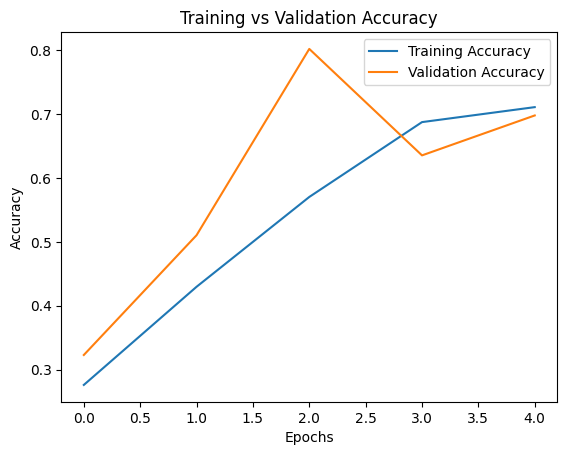

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")

plt.show()

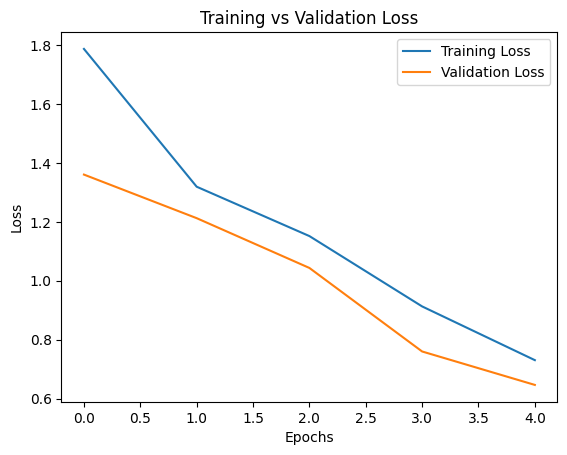

In [26]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.show()

# Task 7 

This computer vision solution can be used in the manufacturing industry for automatic defect detection.

The CNN model can identify defects such as dents, scratches, stains, and damaged surfaces from product images captured during manufacturing.

Using this system helps industries:
1. Improve product quality
2. Reduce manual inspection time
3. Detect defects quickly and accurately
4. Reduce human errors and production costs
5. Increase automation in quality control processes

Such AI-based visual inspection systems are widely used in automobile, electronics, and industrial manufacturing industries.

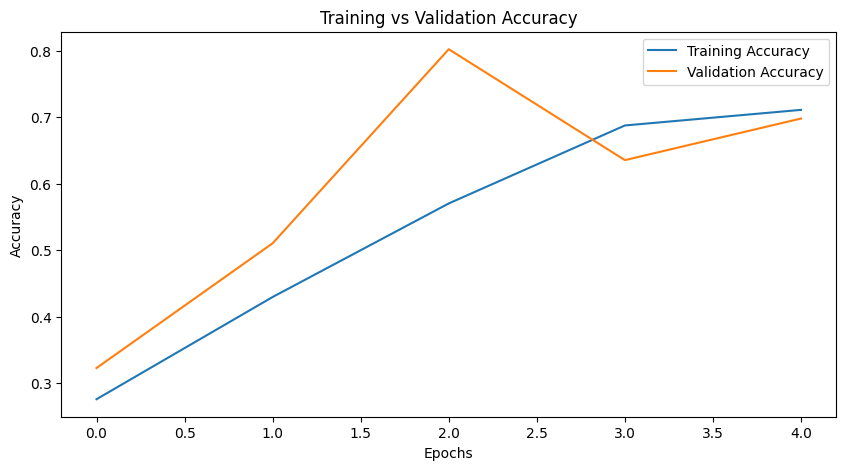

In [27]:
import matplotlib.pyplot as plt
import os

# create results folder
os.makedirs("results", exist_ok=True)

# Accuracy graph
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# save image
plt.savefig("results/accuracy_loss_curves.png")

plt.show()

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import os

# create results folder
os.makedirs("results", exist_ok=True)

y_true = []
y_pred = []

# get predictions batch by batch
for images, labels in test_data:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels)
    y_pred.extend(predicted_labels)

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(cmap="Blues", ax=ax)

# save image
plt.savefig("results/confusion_matrix.png")

plt.show()

KeyboardInterrupt: 

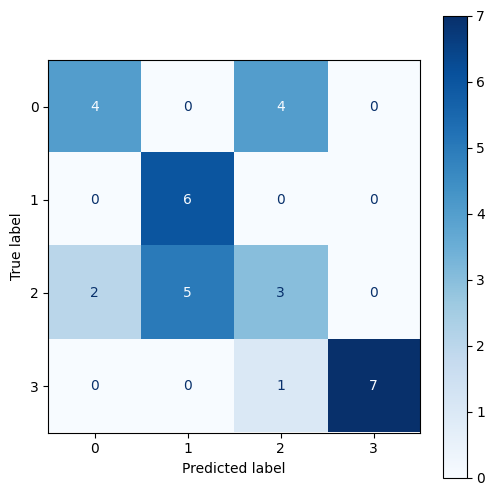

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("results", exist_ok=True)

# take one batch
images, labels = next(iter(test_data))

# predictions
predictions = model.predict(images, verbose=0)

# predicted class
y_pred = np.argmax(predictions, axis=1)

# true class
y_true = np.argmax(labels, axis=1)

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

# display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(cmap="Blues", ax=ax)

# save image
plt.savefig("results/confusion_matrix.png")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step


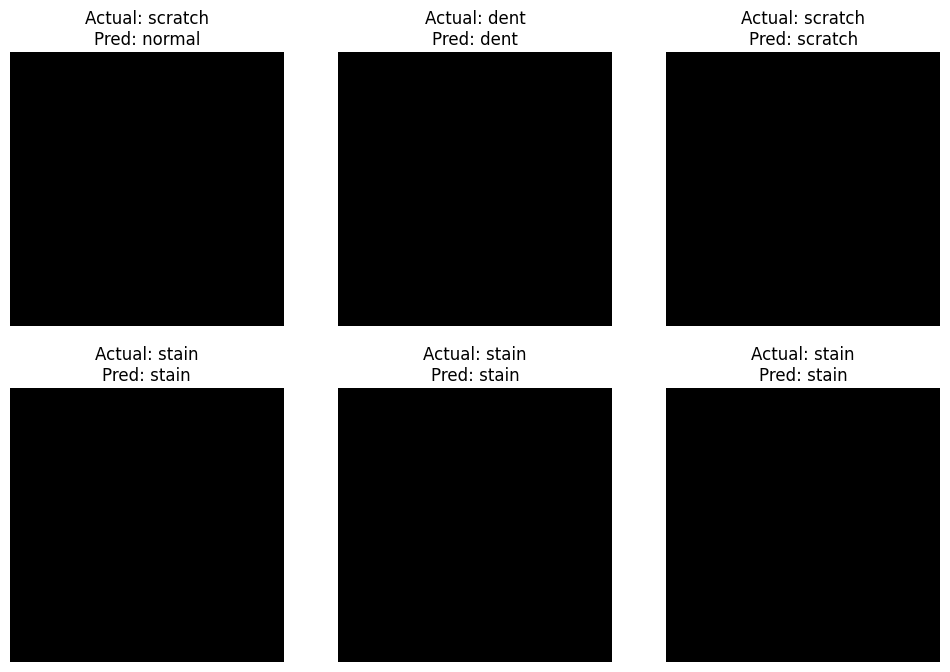

In [33]:
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(12,8))

images, labels = next(test_data)

predictions = model.predict(images)

predicted_labels = np.argmax(predictions, axis=1)

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i].astype("uint8"))

    actual = class_names[np.argmax(labels[i])]
    predicted = class_names[predicted_labels[i]]

    plt.title(f"Actual: {actual}\nPred: {predicted}")

    plt.axis("off")

# save image
plt.savefig("Sample_predictions/prediction_outputs.png")

plt.show()